---
title: Linear Regression
author: Andrei Akopian
date: 2026-02-14
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

Baseline linear regression for unmixing.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sklearn

In [7]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[2]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [8]:
ATMO_DATA = "../../../data/isprs_26_only_vza_rows.csv"
LAB_DATA = "../../../data/useful_columns_data.csv"

In [9]:
df = helper_functions.open_file(LAB_DATA)
fractions, nr900to1690_raw = helper_functions.take_subset(df,start=900,end=1690)

# Naive Linear Regression

A naive linear regression, without adjusting to the specifics of the dataset in anyway.

In [ ]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690_raw, fractions.to_numpy(), test_size=0.2, random_state=42)
naive_regression = sklearn.linear_model.Ridge(alpha=0.0)
naive_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Naive linear regression sticks outside of the [0, 1] range.

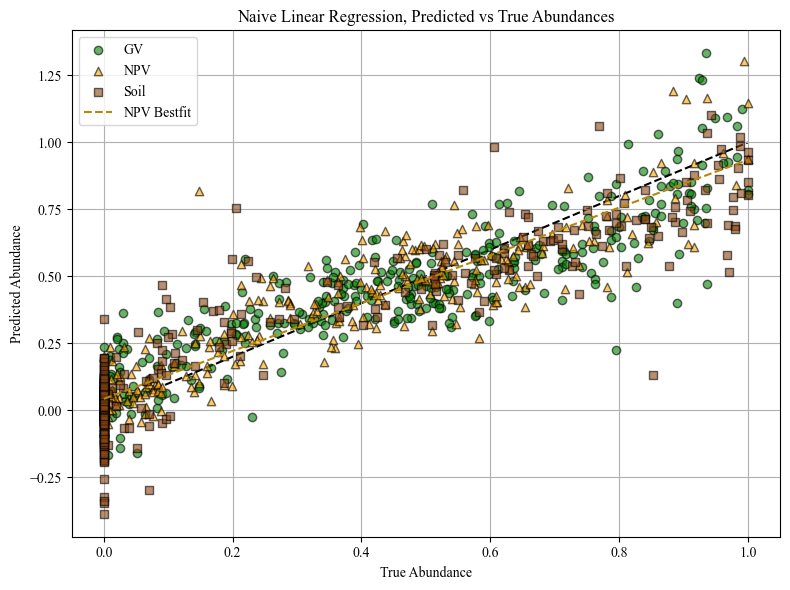

npv r^2 = 0.7686441108947003
gv r^2 = 0.8468129076236593
soil r^2 = 0.8399753536733998
mean r^2 = 0.8184774573972531
rmse = 0.13129861857034938


In [6]:
ab_true_np_array = y_test
ab_predictions = naive_regression.predict(X_test)
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_predictions,
    model_name="Naive Linear Regression",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_predictions)
print(f"rmse = {rmse}")

We clip the predicted abundances to [0,1] range, and visually confirm that the fractions add up roughly to 1.

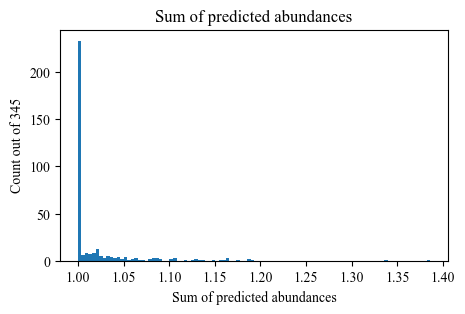

In [20]:
# | output: false
# | code-fold: true
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
helper_functions.simple_histogram(ab_clipped_predictions.sum(axis=1), title="Sum of predicted abundances", x_label="Sum of predicted abundances", y_label=f"Count out of {y_test.shape[0]}", bins=100)

Clipped prediction plot:

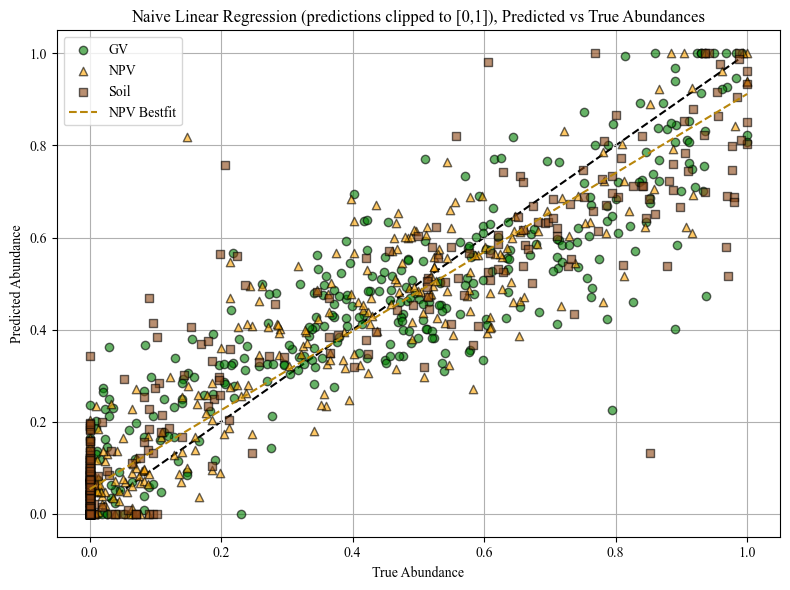

npv r^2 = 0.7902247995893866
gv r^2 = 0.8573417735893353
soil r^2 = 0.8793291115855436
mean r^2 = 0.8422985615880885
rmse = 0.13129861857034938


In [21]:
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_clipped_predictions,
    model_name="Naive Linear Regression (predictions clipped to [0,1])",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_clipped_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_predictions)
print(f"rmse = {rmse}")

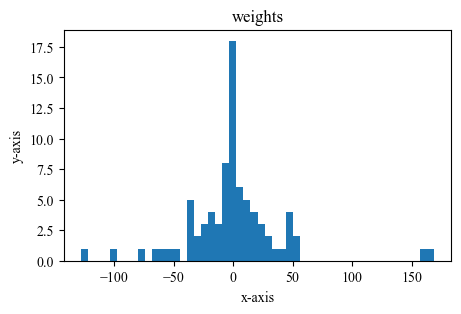

In [20]:
helper_functions.simple_histogram(naive_regression.coef_[0], bins=50, title="weights")

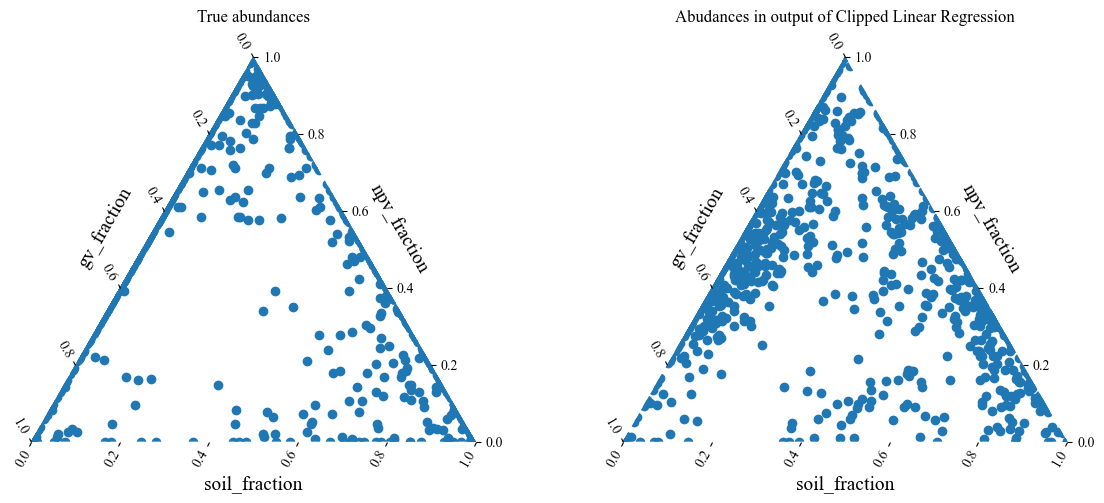

In [10]:
helper_functions.ternary_abundances(y_test, ab_clipped_predictions, model_name="Clipped Linear Regression")

## On Normalized Data
Here we do row wise $L_2$ normalization.

In [10]:
dataset = nr900to1690_raw
# norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
norms = dataset.sum(axis=1).to_numpy()
print(norms.min(), norms.max())
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
# post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
post_norms = normalized_dataset.sum(axis=1)
print(post_norms.min(), post_norms.max())
nr900to1690 = normalized_dataset

8.6551167051 44.43919789800001
0.9999999999999988 1.0000000000000009


In [11]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690, fractions.to_numpy(), test_size=0.2, random_state=42)
normalized_regression = sklearn.linear_model.LinearRegression()
normalized_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


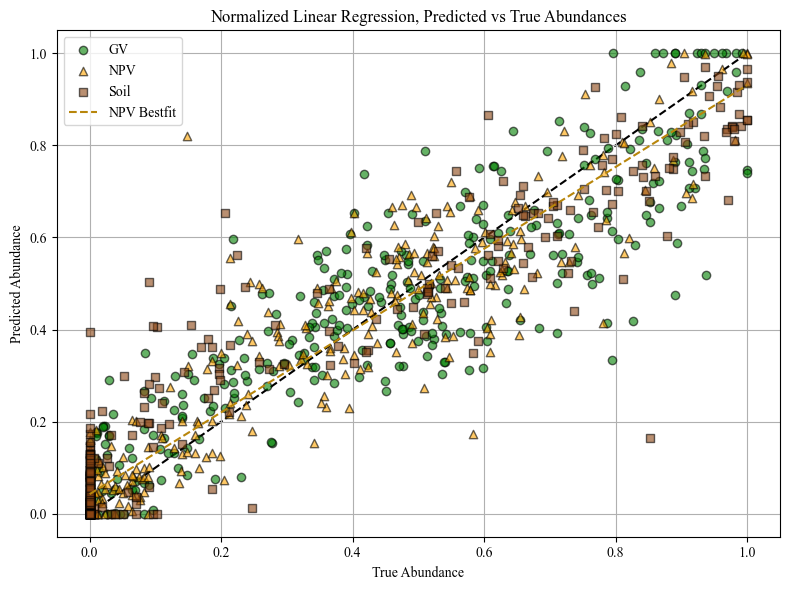

npv r^2 = 0.8141670724739376
gv r^2 = 0.8671650934141869
soil r^2 = 0.9025544338209334
mean r^2 = 0.8612955332363526
rmse = 0.11532366154403788


In [12]:
ab_true_np_array = y_test
ab_predictions = normalized_regression.predict(X_test)
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
ab_clipnormed_predictions = ab_clipped_predictions / ab_clipped_predictions.sum(axis=1)[:, np.newaxis]
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_clipped_predictions,
    model_name="Normalized Linear Regression",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_clipnormed_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_clipnormed_predictions)
print(f"rmse = {rmse}")

### Checking Different Random States
Overly good result:
```
== State 11 ==
npv r^2 = 0.8277290383217878
gv r^2 = 0.8821844039292022
soil r^2 = 0.9205843854137392
mean r^2 = 0.8768326092215762
rmse = 0.10757869079633842
```
Midrange result:
```
== State 6 ==
npv r^2 = 0.7707717944115102
gv r^2 = 0.8860753980619638
soil r^2 = 0.8970468604819483
mean r^2 = 0.8512980176518075
rmse = 0.11553345351122202
```
Bad result:
```
== State 4 ==
npv r^2 = 0.728998683629316
gv r^2 = 0.8550228138493253
soil r^2 = 0.8944640342939832
mean r^2 = 0.8261618439242082
rmse = 0.12435319948311334
```

In [16]:
def check_random_state(random_state: int = 42, plot: bool = False, alpha: float = 0.0) -> tuple[float]:
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690, fractions.to_numpy(), test_size=0.2, random_state=random_state)
    normalized_regression = sklearn.linear_model.Ridge(alpha=alpha)
    normalized_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware
    ab_true_np_array = y_test
    ab_predictions = normalized_regression.predict(X_test)
    ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
    ab_clipnormed_predictions = ab_clipped_predictions / ab_clipped_predictions.sum(axis=1)[:, np.newaxis]
    if plot:
        helper_functions.plot_preds(
            ab_true=ab_true_np_array,
            ab_pred=ab_clipped_predictions,
            model_name=f"Normalized Linear Regression. random_state={random_state}",
            save_path=f"naive_linear_regression_randomstate{random_state}.svg"
        )
    slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_clipnormed_predictions)
    npvr2, gvr2, soilr2, rmse = r[0]**2, r[1]**2, r[2]**2, sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_clipnormed_predictions)
    # print(f"npv r2 = {npvr2} | gv r2 = {gvr2} | soil r2 = {soilr2} | rmse={rmse}")
    return npvr2, gvr2, soilr2, rmse

In [17]:
# Try differnet alpha values
random_state = 42
print("Normalized Lab Data. random_state =", random_state)
for alpha in np.arange(0.0, 1.0, 0.05):
    print("Alpha", round(alpha*alpha, 4))
    npvr2, gvr2, soilr2, rmse = check_random_state(alpha=alpha*alpha)

Normalized Lab Data. random_state = 42
Alpha 0.0
Alpha 0.0025
Alpha 0.01
Alpha 0.0225
Alpha 0.04
Alpha 0.0625
Alpha 0.09
Alpha 0.1225
Alpha 0.16
Alpha 0.2025
Alpha 0.25
Alpha 0.3025
Alpha 0.36
Alpha 0.4225
Alpha 0.49
Alpha 0.5625
Alpha 0.64
Alpha 0.7225
Alpha 0.81
Alpha 0.9025


In [18]:
npvr2s = []
gvr2s = []
soilr2s = []
rmses = []
N = 1000
for state in range(0, N):
    # print(f"== State {state} ==")
    npvr2, gvr2, soilr2, rmse = check_random_state(state)
    npvr2s.append(npvr2)
    gvr2s.append(gvr2)
    soilr2s.append(soilr2)
    rmses.append(rmse)

/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.31979e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.43564e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.65568e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.24379e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/s

In [29]:
avg_npv = np.mean(npvr2s)
avg_gv = np.mean(gvr2s)
avg_soil = np.mean(soilr2s)
avg_rmse = np.mean(rmses)
print(f"avg npv R2 = {avg_npv}, std={np.std(npvr2s)}")
print(f"avg gv R2 = {avg_gv}, std={np.std(gvr2s)}")
print(f"avg soil R2 = {avg_soil}, std={np.std(soilr2s)}")
print(f"avg rmse = {avg_rmse}, std={np.std(rmses)}")
print(f"avg mean R2 = {(avg_npv + avg_gv + avg_soil) / 3}, std={np.std((np.array(npvr2s) + np.array(gvr2s) + np.array(soilr2s)) / 3)}")

avg npv R2 = 0.7801912658301997, std=0.020214342726530676
avg gv R2 = 0.8741434648013844, std=0.014490078351320781
avg soil R2 = 0.9069072847573152, std=0.012852964046194695
avg rmse = 0.11635574307023631, std=0.004293513773710149
avg mean R2 = 0.8537473384629664, std=0.012312131824604841


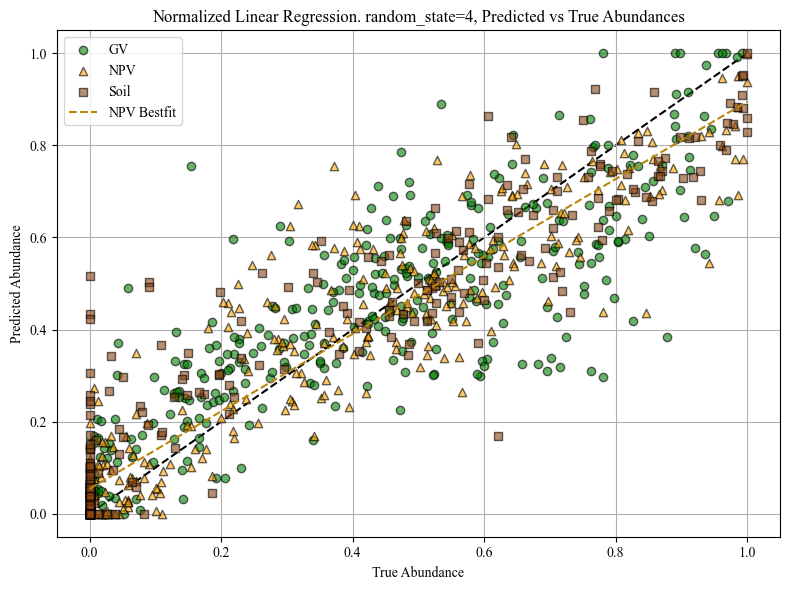

/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.25371e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


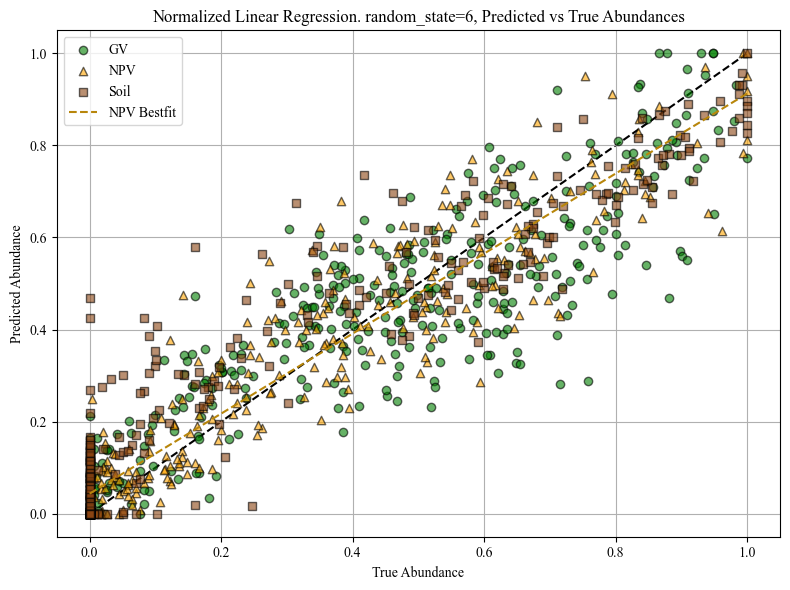

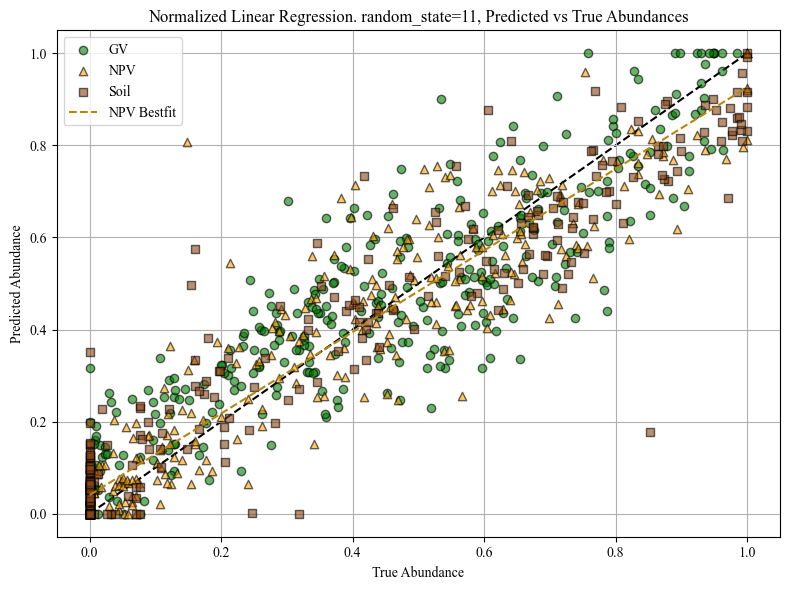

(np.float64(0.8271545339479012),
 np.float64(0.8815437684707769),
 np.float64(0.9211796723802906),
 0.10768935246581213)

In [19]:
check_random_state(4, True)
check_random_state(6, True)
check_random_state(11, True)

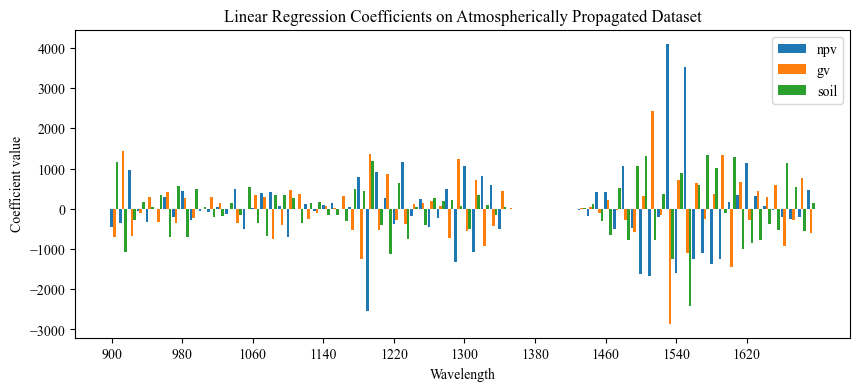

In [36]:
n = len(normalized_regression.coef_[0])

plt.figure(figsize=(10, 4))
bar_width = 0.3
x_range = np.arange(0, n, 1)
plt.bar(x_range + bar_width*0.0, normalized_regression.coef_[0], width=bar_width, label="npv")
plt.bar(x_range + bar_width*1, normalized_regression.coef_[1], width=bar_width, label="gv")
plt.bar(x_range + bar_width*2, normalized_regression.coef_[2], width=bar_width, label="soil")

step = max(1, n // 10)  # show ~10 labels
plt.xticks(range(0, n, step), nr900to1690_raw.columns[::step], rotation=0)
plt.xlabel("Wavelength")
plt.ylabel("Coefficient value")
plt.legend()

plt.title(f"Linear Regression Coefficients on Atmospherically Propagated Dataset")
plt.savefig("lr_coefs_on_lab_data.svg", format="svg")

plt.show()

# Better Linear Regression

The naive linear regression, has a number of drawbacks, such as forcing values to be clipped.

Also, naive linear regression ignored rows that were missing one of the 3 abundances. ([See `dataset_characterization.ipynb`](../characterization/dataset_characterization.ipynb))

This linear regression model will:
- train the abundanees separately, only using
- transform the results using a logit function into the [0, 1] range instead of clipping

In [17]:
logit = lambda x: scipy.special.logit((x-np.float64(0.5))*np.float64(0.90)+np.float64(0.5))
expit = scipy.special.expit

In [18]:
X_train_raw, X_test_raw, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690, fractions, test_size=0.5, random_state=42)

def normalize(frame):
    return sklearn.preprocessing.normalize(frame,norm='l2',axis=1)

npv_indecies = {i for i, value in enumerate(df['has_npv']) if value}
gv_indecies = {i for i, value in enumerate(df['has_gv']) if value}
soil_indecies = {i for i, value in enumerate(df['has_soil']) if value}
training_indecies = set(X_train.index)

# fit regressions
npv_train_indecies = list(training_indecies.intersection(npv_indecies))
npv_regression = sklearn.linear_model.LinearRegression()
npv_train = logit(y_train.loc[npv_train_indecies]['npv_fraction'].to_numpy())
npv_regression.fit(normalize(X_train.loc[npv_train_indecies]), npv_train)

gv_train_indecies = list(training_indecies.intersection(gv_indecies))
gv_regression = sklearn.linear_model.LinearRegression()
gv_train = logit(y_train.loc[gv_train_indecies]['gv_fraction'].to_numpy())
gv_regression.fit(normalize(X_train.loc[gv_train_indecies]), gv_train)

soil_train_indecies = list(training_indecies.intersection(soil_indecies))
soil_regression = sklearn.linear_model.LinearRegression()
soil_train = logit(y_train.loc[soil_train_indecies]['soil_fraction'].to_numpy())
soil_regression.fit(normalize(X_train.loc[soil_train_indecies]), soil_train)

NameError: name 'nr900to1690' is not defined

In [14]:
testing_indecies = X_test.index
prediction_buffer = np.array([[0.0,0.0,0.0] for i in testing_indecies])
npv_preds = expit(npv_regression.predict(normalize(X_test)))
gv_preds = expit(gv_regression.predict(normalize(X_test)))
soil_preds = expit(soil_regression.predict(normalize(X_test)))

for i, index in enumerate(testing_indecies):
    if index in npv_indecies:
        prediction_buffer[i][0] = npv_preds[i]
    if index in gv_indecies:
        prediction_buffer[i][1] = np.float64(gv_preds[i])
    if index in soil_indecies:
        prediction_buffer[i][2] = np.float64(soil_preds[i])
        

NameError: name 'expit' is not defined

In [27]:
# | output: false
# | code-fold: true
sums = np.sum(prediction_buffer, axis=1)
ab_clipnormed_predictions = np.array([prediction_buffer[i]/s for i, s in enumerate(sums)])
print(ab_clipnormed_predictions.sum(axis=1).min(), ab_clipnormed_predictions.sum(axis=1).max())

0.9999999999999998 1.0000000000000002


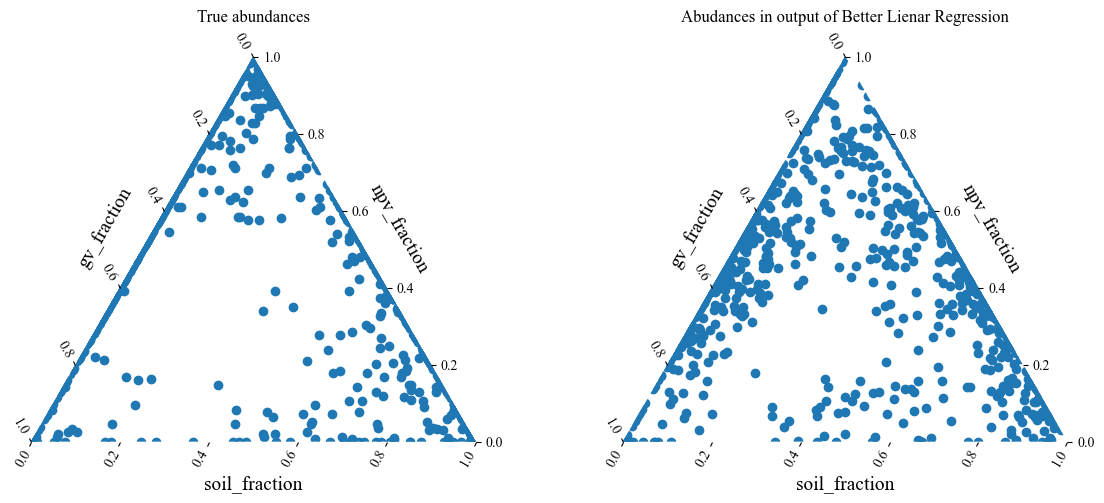

In [28]:
helper_functions.ternary_abundances(y_test, ab_clipped_predictions, model_name="Better Lienar Regression")

In [11]:
helper_functions.plot_preds(
    ab_true=y_test.to_numpy(), 
    ab_pred=ab_clipnormed_predictions, 
    save_path="better_linear_regression.svg",
    model_name="Better Linear Regression"
)
slope, intercept, r, p, se = scipy.stats.linregress(y_test.to_numpy(), ab_clipnormed_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_predictions)
print(f"rmse = {rmse}")

AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

# Atmospheric Data

### Ridge Regression
The following demonstractions are best made using Ridge Regression. Note that Ridge Regression with `alpha=0.0` is equivalent to traditional Linear Regression.

In [12]:
df = helper_functions.open_file(ATMO_DATA)
at_fractions, at900to1690 = helper_functions.take_subset(df, 900, 1690)
assert all(at_fractions['gv_fraction'] == 0)
at_fractions = at_fractions[["npv_fraction", "soil_fraction"]]

In [14]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(at900to1690, at_fractions, test_size=0.2, random_state=42)
alpha = 0
ridge_regression = sklearn.linear_model.Ridge(alpha=alpha)
ridge_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware
print(ridge_regression.coef_[0])
print(f"Train r2: {ridge_regression.score(X_train, y_train)}")
print(f"Test r2: {ridge_regression.score(X_test, y_test)}")
y_pred = ridge_regression.predict(X_test)
rmse = sklearn.metrics.root_mean_squared_error(y_test, y_pred)
print(f"rmse = {rmse}")

[ -434.33624777   134.14424137   938.63531544   -53.86507464
   119.69315418  -577.5268749    310.59697368    -2.54641184
   240.07792217  -914.83212921    33.21940704  -522.77349417
  -343.12433333   334.45561204   852.27338298  -478.39990804
   338.89058688  1055.73186611  -438.6071534   -156.00315724
  -440.33065301   423.16785703  -429.21538517   328.48285632
   -99.13988815 -1014.99123805   144.81735052     4.65376474
  -194.69069996   110.1432552    558.09373805    96.33672824
   225.95009274  -449.96691285    81.8121202    -86.39659457
   -71.25510997  -716.84507714    63.54507525   484.61904215
   -93.33147729  -139.22527141   538.11279364  -217.51767876
   198.10830753    16.05024723    60.82980367     4.42222968
   199.20310625  -578.03610329  -284.28452266   138.21962632
   102.7583063    682.80774947  -171.3698701   1072.65306209
   -52.0422009   -292.00200324   481.25645946 -1034.05654531
  -124.07813832  -443.92585565   301.08202548  -325.69406232
   404.5194974    390.87

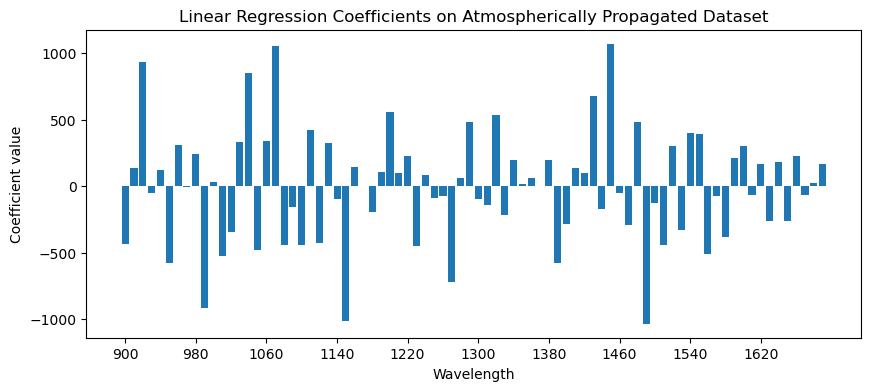

In [17]:
coeffs = ridge_regression.coef_[0]
n = len(coeffs)

plt.figure(figsize=(10, 4))
plt.bar(range(n), coeffs)

step = max(1, n // 10)  # show ~10 labels
plt.xticks(range(0, n, step), at900to1690.columns[::step], rotation=0)
plt.xlabel("Wavelength")
plt.ylabel("Coefficient value")
# plt.title(f"Ridge Regression ($\\alpha$={alpha}) Coefficients on Atmospherically Propagated Dataset")

assert alpha == 0
plt.title(f"Linear Regression Coefficients on Atmospherically Propagated Dataset")
plt.savefig("lr_coefs_on_atmo_data.svg", format="svg")

plt.show()

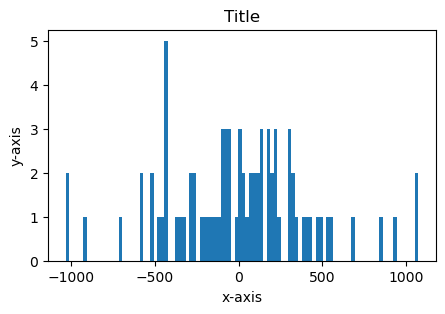

In [9]:
helper_functions.simple_histogram(ridge_regression.coef_[0], bins=100)

In [44]:
ab_true_np_array = y_test.to_numpy()
ab_predictions = ridge_regression.predict(X_test)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"soil r^2 = {r[1]**2}")
print(f"mean r^2 = {np.square(r).mean()}")

npv r^2 = 0.02107261229470254
soil r^2 = 0.02107261229456374
mean r^2 = 0.021072612294633142


### Pre-Training on Lab Data

**Result: Failure**, no meaningful predictive power.

In [5]:
lbdf = helper_functions.open_file(LAB_DATA)
lbfractions, lb900to1690_raw = helper_functions.take_subset(lbdf,start=900,end=1690)
atdf = helper_functions.open_file(ATMO_DATA)
atfractions, at900to1690_raw = helper_functions.take_subset(atdf,start=900,end=1690)

In [6]:
# L2 norm on lab data
dataset = lb900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
lb900to1690 = normalized_dataset

L1 before normalization: min=1.0853925339623511 max=4.995320587151579
L1 after normalization: min=0.9999999999999994 max=1.0000000000000007


In [7]:
# L2 norm on atmo data
dataset = at900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
at900to1690 = normalized_dataset

L1 before normalization: min=0.07422868006799167 max=5.547629854271101
L1 after normalization: min=0.9999999999999996 max=1.0000000000000002


In [4]:
# Normal KNN regression
# should take <1min to run
r2_score = sklearn.metrics.r2_score
root_mean_squared_error = sklearn.metrics.r2_score

X_lb_train, y_lb_train = lb900to1690, lbfractions, 
X_at_train, X_test, y_at_train, y_test = sklearn.model_selection.train_test_split(at900to1690, atfractions, test_size=0.5, random_state=42)

X_train = np.concat([X_lb_train, X_at_train])
y_train = np.concat([y_lb_train, y_at_train])
factor = X_lb_train.shape[0] / y_at_train.shape[0]
sample_weight = [1] * X_lb_train.shape[0] + [factor] * X_at_train.shape[0]

lr = sklearn.linear_model.Ridge(alpha=0)
lr.fit(X_train, y_train, sample_weight=sample_weight)
y_pred = lr.predict(X_test)
current_r2 = r2_score(y_test, y_pred)

print(f"with R² of {current_r2:.4f}")

ab_true_np_array = y_test
ab_predictions = y_pred
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
ab_clipnormed_predictions = ab_clipped_predictions / ab_clipped_predictions.sum(axis=1)[:, np.newaxis]
y_pred = ab_clipnormed_predictions

# y_pred = scipy.special.expit(y_pred)

helper_functions.simple_histogram([y[0] for y in y_pred ], title='npv predicted', bins=100)
helper_functions.simple_histogram([y_test.loc[i, 'npv_fraction'] for i in y_test.index], title='npv actual', bins=100)

print("- npv with an R² of", r2_score(y_test['npv_fraction'], [p[0] for p in y_pred]))
print("- gv with an R² of", r2_score(y_test['gv_fraction'], [p[1] for p in y_pred]))
print("- soil with an R² of", r2_score(y_test['soil_fraction'], [p[2] for p in y_pred]))
rmse = root_mean_squared_error(y_test, y_pred)
print(f"rmse = {rmse}")

NameError: name 'lb900to1690' is not defined